<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TEG003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

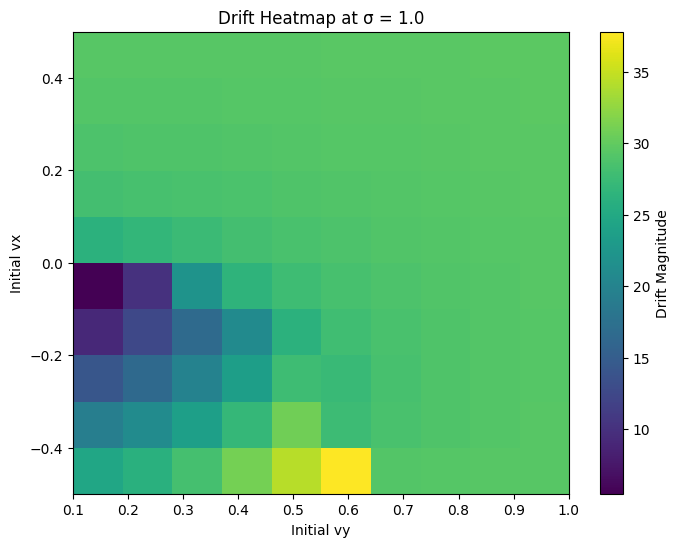

In [1]:
# 🧬 TEG003: Bifurcation Thresholds
# Maps drift, lensing, and collapse regimes by scanning initial velocity and curvature strength
# Author: Chris & Copilot | Arc VIII: Tensorial Emergence

import numpy as np
import matplotlib.pyplot as plt

# 📐 Curvature Tensor
def curvature_tensor(x, y, sigma=1.0):
    exp_term = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    Cxx = (1 - x**2 / sigma**2) * exp_term
    Cyy = (1 - y**2 / sigma**2) * exp_term
    Cxy = (-x * y / sigma**2) * exp_term
    return np.array([[Cxx, Cxy], [Cxy, Cyy]])

# 🧲 Tensor Force
def tensor_force(x, y, vx, vy, sigma=1.0):
    C = curvature_tensor(x, y, sigma)
    v = np.array([vx, vy])
    f = -np.dot(C, v)
    return f[0], f[1]

# 🔁 Velocity Update
def update_velocity(vx, vy, fx, fy, dt):
    return vx + fx * dt, vy + fy * dt

# 🚀 Simulation Loop
def simulate_orbit(x0, y0, vx0, vy0, steps=5000, dt=0.01, sigma=1.0):
    x, y = x0, y0
    vx, vy = vx0, vy0
    trajectory = []

    for _ in range(steps):
        fx, fy = tensor_force(x, y, vx, vy, sigma)
        vx, vy = update_velocity(vx, vy, fx, fy, dt)
        x += vx * dt
        y += vy * dt
        trajectory.append((x, y))

    return np.array(trajectory)

# 🧭 Drift Detection
def detect_drift(trajectory, initial_velocity, dt):
    final_displacement = trajectory[-1] - trajectory[0]
    expected_displacement = np.array(initial_velocity) * dt * len(trajectory)
    drift_vector = final_displacement - expected_displacement
    drift_magnitude = np.linalg.norm(drift_vector)
    return drift_magnitude

# 📊 Bifurcation Scan
def scan_bifurcation(vx_range, vy_range, sigma_values, x0=1.0, y0=0.0, steps=5000, dt=0.01):
    results = []

    for sigma in sigma_values:
        for vx0 in vx_range:
            for vy0 in vy_range:
                trajectory = simulate_orbit(x0, y0, vx0, vy0, steps, dt, sigma)
                drift = detect_drift(trajectory, (vx0, vy0), dt)
                results.append((vx0, vy0, sigma, drift))

    return results

# 📊 Plot Drift Heatmap
def plot_drift_heatmap(results, vx_range, vy_range, sigma):
    drift_matrix = np.zeros((len(vx_range), len(vy_range)))

    for vx0, vy0, s, drift in results:
        if np.isclose(s, sigma):
            i = vx_range.index(vx0)
            j = vy_range.index(vy0)
            drift_matrix[i, j] = drift

    plt.figure(figsize=(8, 6))
    plt.imshow(drift_matrix, origin='lower', extent=[min(vy_range), max(vy_range), min(vx_range), max(vx_range)],
               aspect='auto', cmap='viridis')
    plt.colorbar(label='Drift Magnitude')
    plt.title(f"Drift Heatmap at σ = {sigma}")
    plt.xlabel("Initial vy")
    plt.ylabel("Initial vx")
    plt.show()

# 🧪 Run Scan
vx_range = np.linspace(-0.5, 0.5, 10).tolist()
vy_range = np.linspace(0.1, 1.0, 10).tolist()
sigma_values = [0.5, 1.0, 2.0]

results = scan_bifurcation(vx_range, vy_range, sigma_values)
plot_drift_heatmap(results, vx_range, vy_range, sigma=1.0)
